<a href="https://colab.research.google.com/github/yunirajagukguk/Analisis-dan-Visualisasi-Data_Tugas-5/blob/main/House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [10]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

Membaca dataset

In [11]:
df = pd.read_csv('train.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0       Norm     1Fam     2Story            7          

In [12]:
print("Ukuran dataset sebelum cleansing:", df.shape)

Ukuran dataset sebelum cleansing: (1460, 81)


Cek Jumlah missing value

In [13]:
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())


Jumlah missing value per kolom:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


**Exploratory Data Analysis (EDA)**

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

Statistik Deskriptif

In [15]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Distribusi Harga Rumah (SalePrice)

Karena SalePrice adalah target utama.

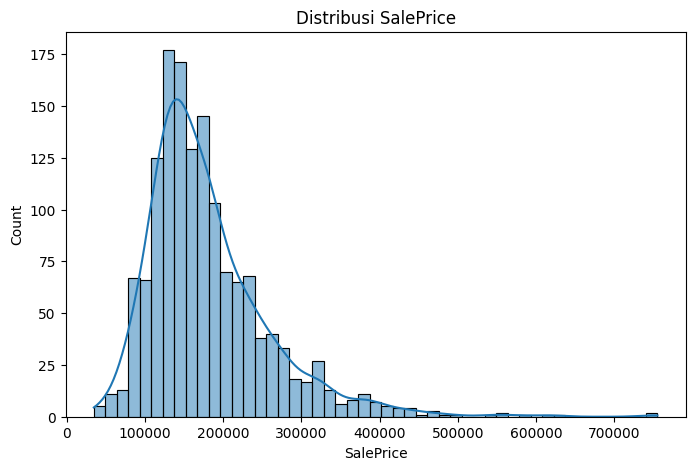

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['SalePrice'],
    kde=True
)

plt.title('Distribusi SalePrice')
plt.show()

Boxplot SalePrice

Mendeteksi outlier.

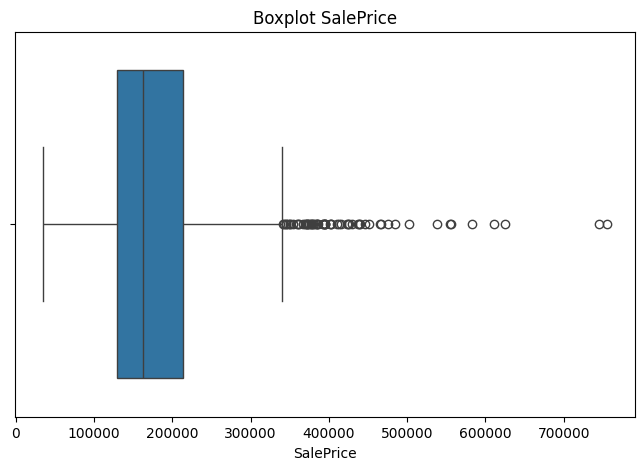

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['SalePrice']
)

plt.title('Boxplot SalePrice')
plt.show()

Korelasi Antar Variabel Numerik

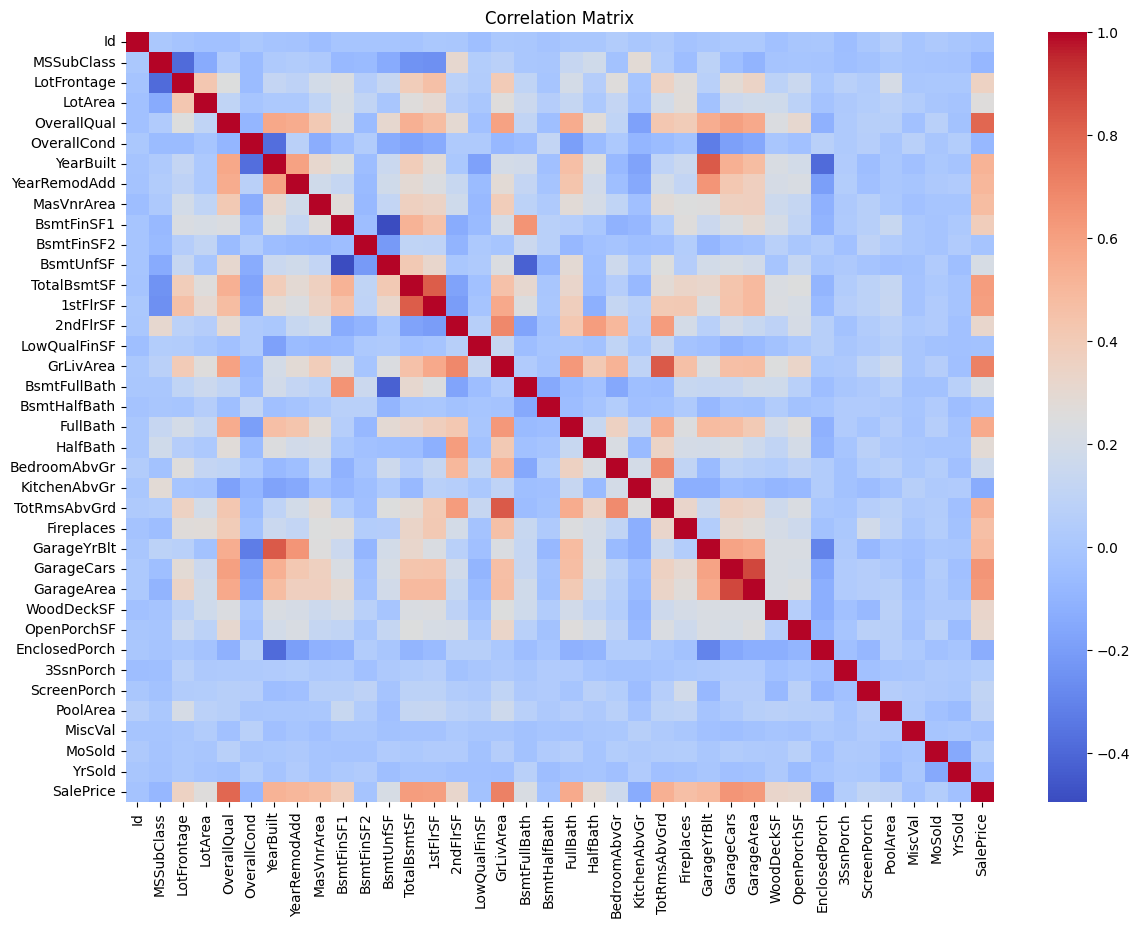

In [22]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

Top 10 Fitur yang Paling Berpengaruh Terhadap SalePrice

In [23]:
corr_target = corr_matrix['SalePrice'].sort_values(
    ascending=False
)

print(corr_target.head(11))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


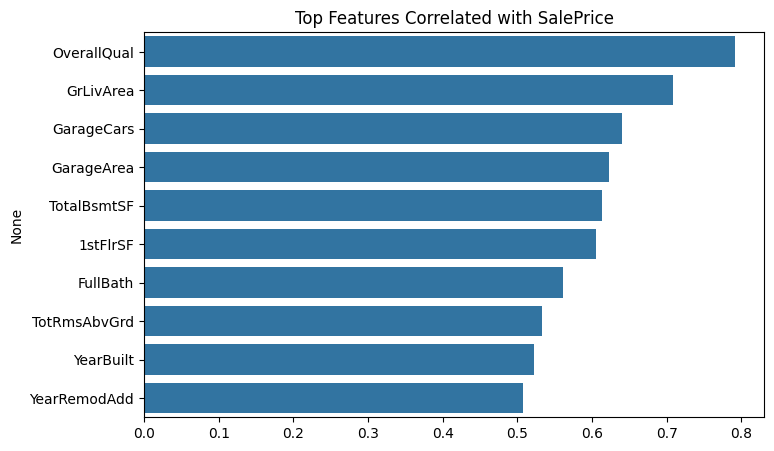

In [24]:
top_corr = corr_target[1:11]

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title('Top Features Correlated with SalePrice')
plt.show()

Hubungan Top Fitur(OverallQual) dengan SalePrice

Semakin tinggi kualitas bangunan, semakin tinggi harga rumah.

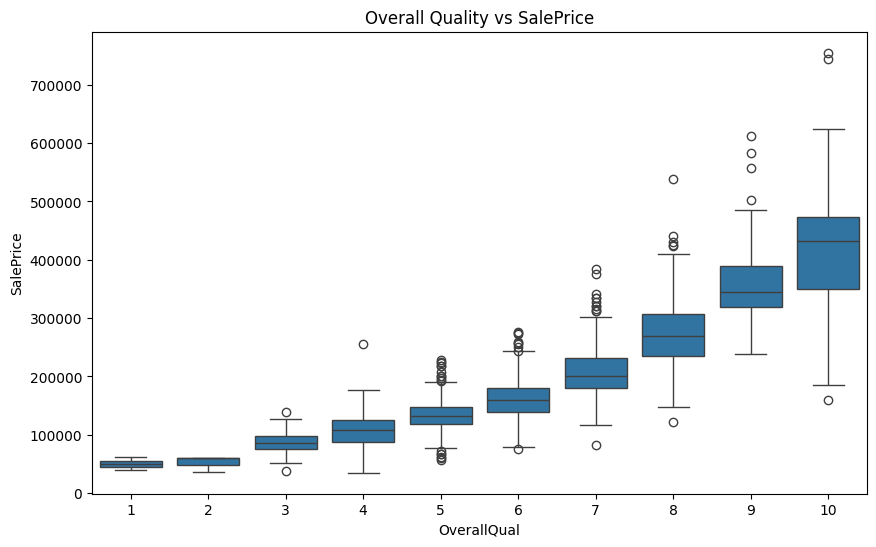

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df
)

plt.title('Overall Quality vs SalePrice')
plt.show()

Hubungan GrLivArea dengan SalePrice

Semakin luas area hunian, semakin mahal harga rumah.

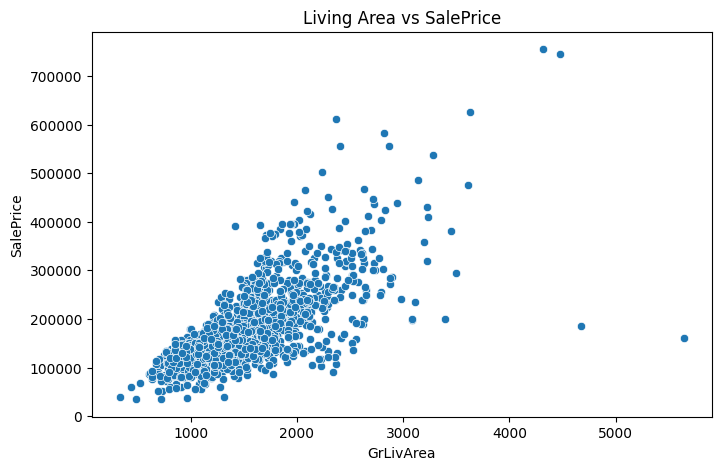

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=df
)

plt.title('Living Area vs SalePrice')
plt.show()

Hubungan GarageCars dengan SalePrice

Rumah dengan kapasitas garasi lebih besar cenderung memiliki harga lebih tinggi.

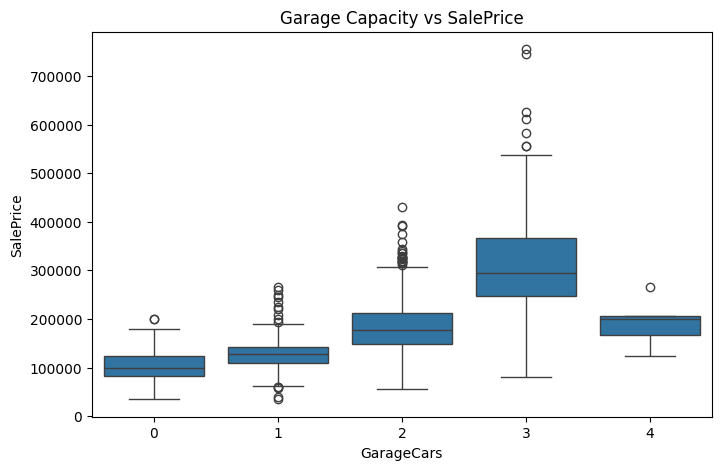

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='GarageCars',
    y='SalePrice',
    data=df
)

plt.title('Garage Capacity vs SalePrice')
plt.show()

Distribusi Fitur Kategorikal Penting
Neighborhood

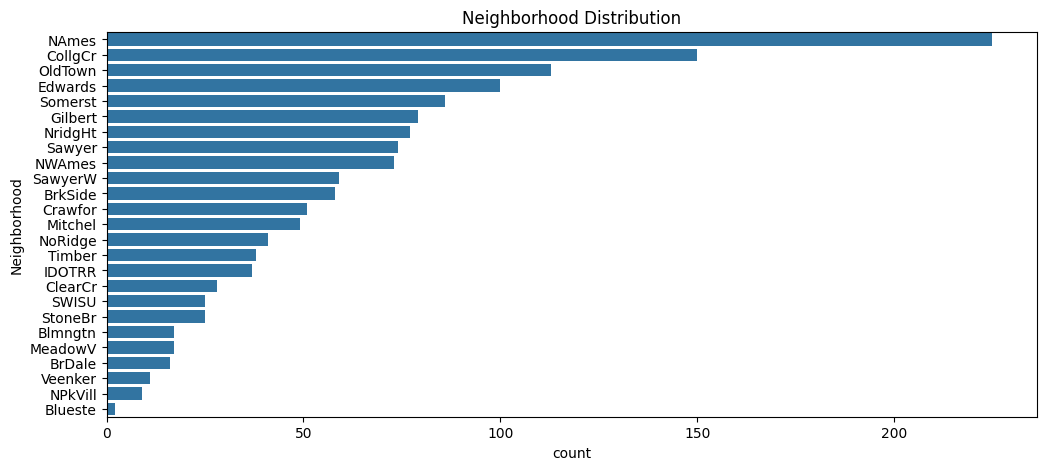

In [32]:
plt.figure(figsize=(12,5))

sns.countplot(
    y='Neighborhood',
    data=df,
    order=df['Neighborhood'].value_counts().index
)

plt.title('Neighborhood Distribution')
plt.show()

SalePrice Berdasarkan Neighborhood

Lokasi rumah sangat mempengaruhi harga jual.

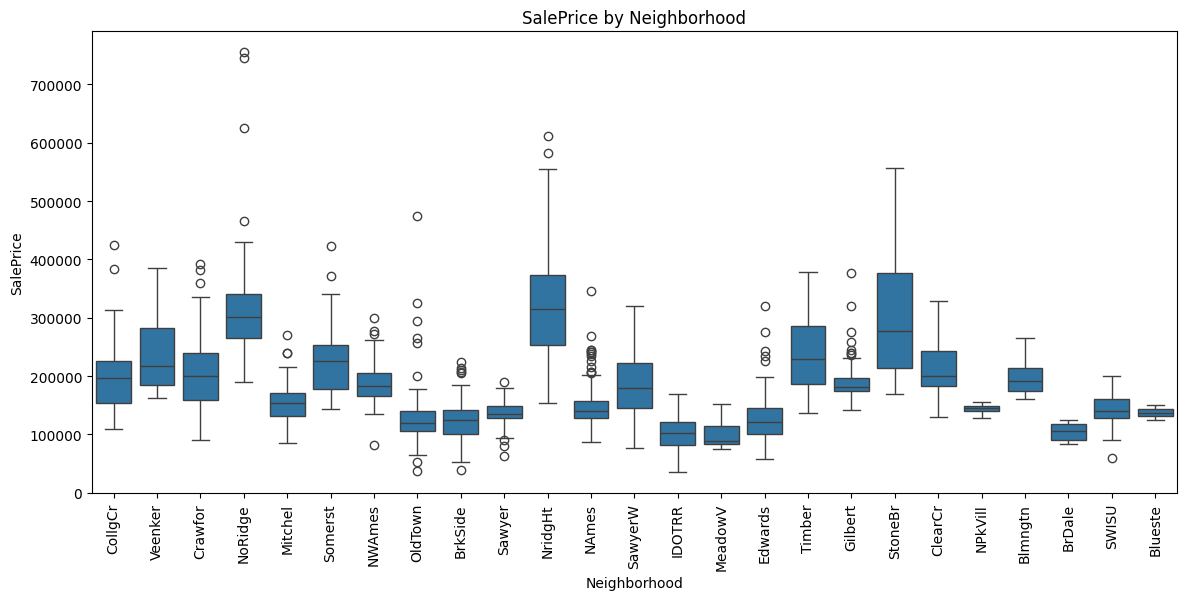

In [34]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='Neighborhood',
    y='SalePrice',
    data=df
)

plt.xticks(rotation=90)

plt.title('SalePrice by Neighborhood')
plt.show()

Distribusi Tahun Pembangunan

Menunjukkan tren pembangunan rumah dari tahun ke tahun.

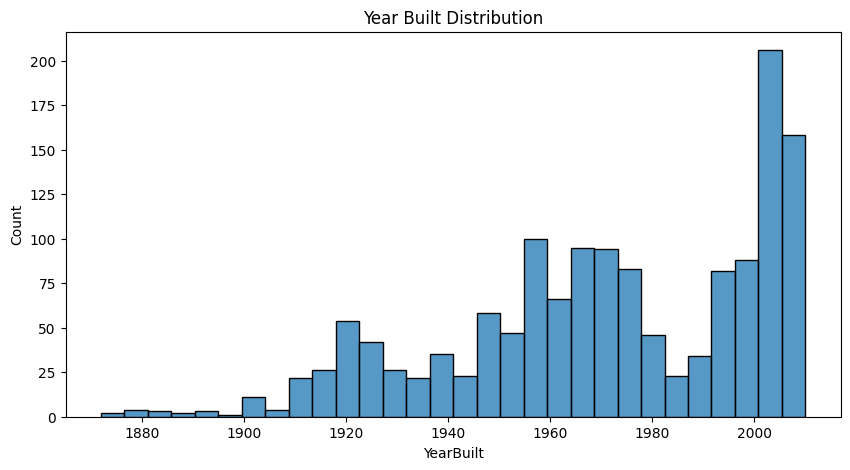

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['YearBuilt'],
    bins=30
)

plt.title('Year Built Distribution')
plt.show()

**Feature Engineering**

Dimension Reduction (PCA)

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Pisahkan fitur dan target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

Standardisasi Data

In [40]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identify categorical columns
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, dummy_na=False)

# Replace any remaining infinite values with NaN and then impute them with the mean
X_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)

# Handle potential NaN values after encoding by imputing them with the mean
# This might happen if 'dummy_na' is False and a column had NaN values, or if a column was purely numerical and had NaNs.
for col in X_encoded.columns:
    if X_encoded[col].isnull().any():
        X_encoded[col] = X_encoded[col].fillna(X_encoded[col].mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

Menentukan Jumlah Komponen PCA

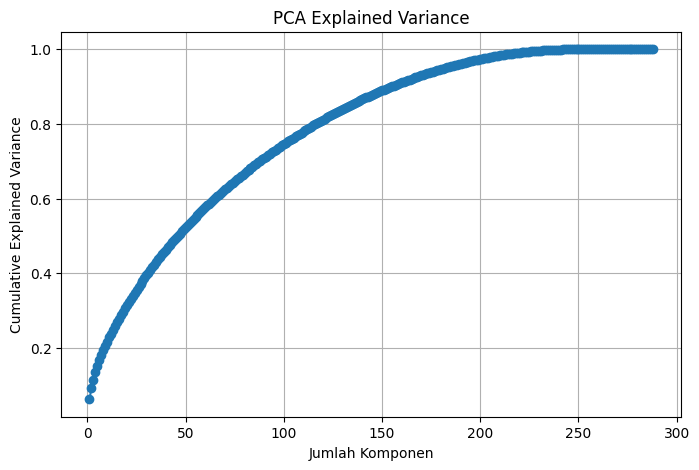

In [41]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained_var)+1),
    explained_var,
    marker='o'
)

plt.xlabel('Jumlah Komponen')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

Memilih Komponen yang Menjelaskan 95% Variansi

In [42]:
n_components = np.argmax(
    explained_var >= 0.95
) + 1

print(
    "Jumlah komponen:",
    n_components
)

Jumlah komponen: 183


PCA Final

In [43]:
pca = PCA(
    n_components=n_components
)

X_reduced = pca.fit_transform(
    X_scaled
)

print(
    "Shape sebelum PCA:",
    X_scaled.shape
)

print(
    "Shape sesudah PCA:",
    X_reduced.shape
)

Shape sebelum PCA: (1460, 288)
Shape sesudah PCA: (1460, 183)


**Model Clustering**

Metode Elbow Method

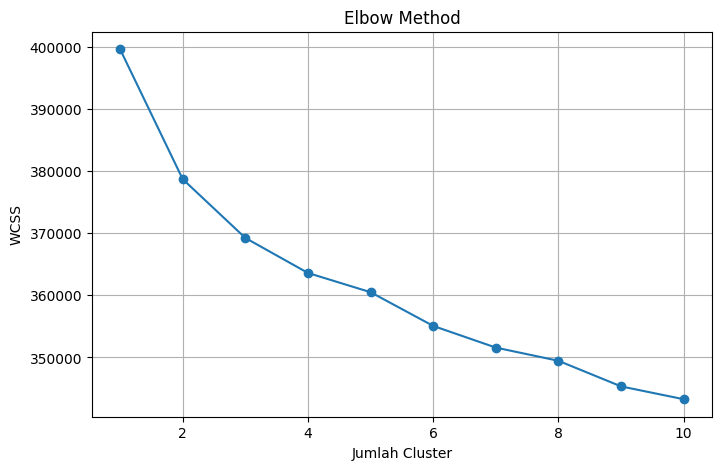

In [44]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_reduced)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

Silhouette Score

In [45]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_reduced
    )

    score = silhouette_score(
        X_reduced,
        labels
    )

    print(
        f'K={k} -> Silhouette Score={score:.4f}'
    )

K=2 -> Silhouette Score=0.0506
K=3 -> Silhouette Score=0.0386
K=4 -> Silhouette Score=0.0134
K=5 -> Silhouette Score=0.0104
K=6 -> Silhouette Score=-0.0097
K=7 -> Silhouette Score=0.0176
K=8 -> Silhouette Score=0.0008
K=9 -> Silhouette Score=0.0146
K=10 -> Silhouette Score=-0.0031


Model Clustering Final

In [48]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    X_reduced
)

Jumlah Data Setiap Cluster

In [51]:
print(
    df['Cluster']
    .value_counts()
)

Cluster
1    871
0    589
Name: count, dtype: int64


Analisis Segmentasi Rumah

In [53]:
segmentasi = df.groupby('Cluster')[[
    'SalePrice',
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'YearBuilt'
]].mean().round(2)

print(segmentasi)

         SalePrice  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt
Cluster                                                                       
0        240337.66         7.26    1765.74        2.28      1265.49    2000.01
1        140741.75         5.32    1346.22        1.42       916.73    1951.83


**Model Random Forest Regressor**

In [55]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Evaluasi Random Forest

In [56]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("=== Random Forest ===")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

=== Random Forest ===
MAE : 20293.170074655653
RMSE : 34501.39866704017
R2 : 0.8448114880868193


**Model XGBoost Regressor**

In [57]:
!pip install xgboost

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

Evaluasi XGBoost

In [58]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("=== XGBoost ===")
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R2 :", xgb_r2)

=== XGBoost ===
MAE : 19191.654296875
RMSE : 34322.618081958724
R2 : 0.846415638923645


Perbandingan Kedua Model

In [59]:
hasil = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        rf_rmse,
        xgb_rmse
    ],
    'R2': [
        rf_r2,
        xgb_r2
    ]
})

print(hasil)

           Model           MAE          RMSE        R2
0  Random Forest  20293.170075  34501.398667  0.844811
1        XGBoost  19191.654297  34322.618082  0.846416


In [60]:
hasil.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
1,XGBoost,19191.654297,34322.618082,0.846416
0,Random Forest,20293.170075,34501.398667,0.844811


**Visualisasi Perbandingan**

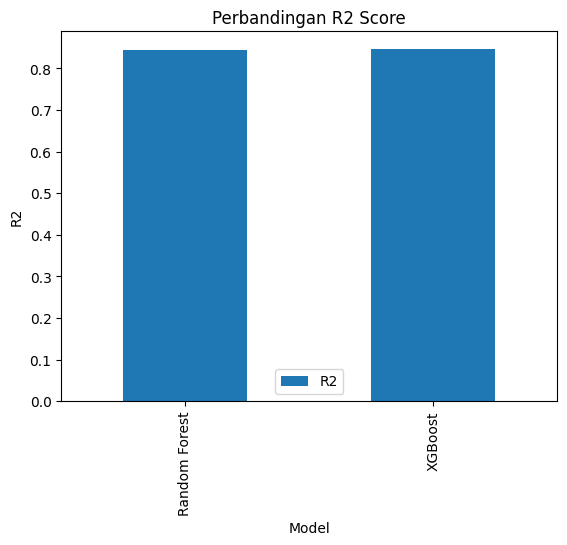

In [61]:
import matplotlib.pyplot as plt

hasil.set_index('Model')[['R2']].plot(
    kind='bar'
)

plt.title('Perbandingan R2 Score')
plt.ylabel('R2')
plt.show()

Menampilkan Prediksi vs Aktual

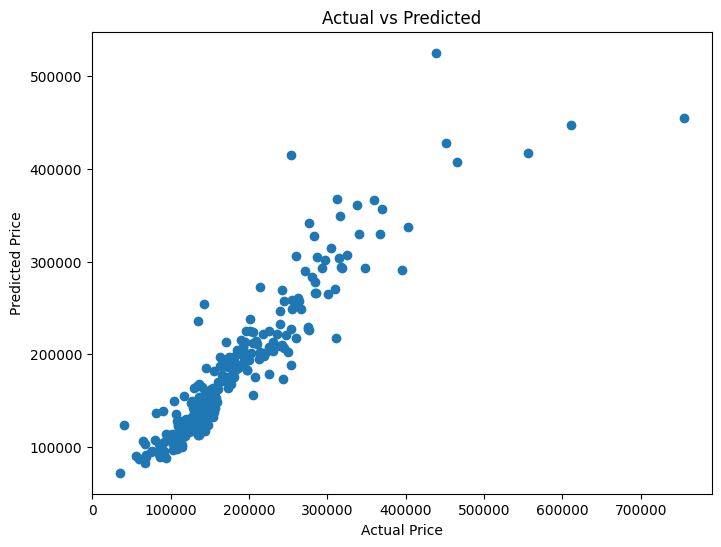

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_pred
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()